# LLM Posterior — ARC-AGI Explorer
Load tasks, inspect prompts, run LOO on a single task, and visualize results.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve()))

from dotenv import load_dotenv
load_dotenv()

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

from src.data_loader import load_task, load_all_tasks
from src.grid_utils import grid_to_str, grids_match, grid_diff, ARC_COLORS
from src.hypothesis_agent import build_prompt, generate_hypothesis
from src.leave_one_out import run_task_loo
from src.evaluate import evaluate_task

TASK_DIR = pathlib.Path("data/ARC-AGI/data/training")
print(f"Tasks available: {len(list(TASK_DIR.glob('*.json')))}")

Tasks available: 400


## 1. Pick a task and inspect it

In [2]:
# Change TASK_ID to any stem from data/ARC-AGI/data/training/
TASK_ID = "007bbfb7"

task = load_task(TASK_DIR / f"{TASK_ID}.json")
print(f"Task: {task.task_id}")
print(f"Train pairs: {len(task.train)}")
print(f"Test pairs:  {len(task.test)}")
print(f"\nTrain[0] input shape:  {len(task.train[0].input)} x {len(task.train[0].input[0])}")
print(f"Train[0] output shape: {len(task.train[0].output)} x {len(task.train[0].output[0])}")

Task: 007bbfb7
Train pairs: 5
Test pairs:  1

Train[0] input shape:  3 x 3
Train[0] output shape: 9 x 9


## 2. Visualize all train pairs

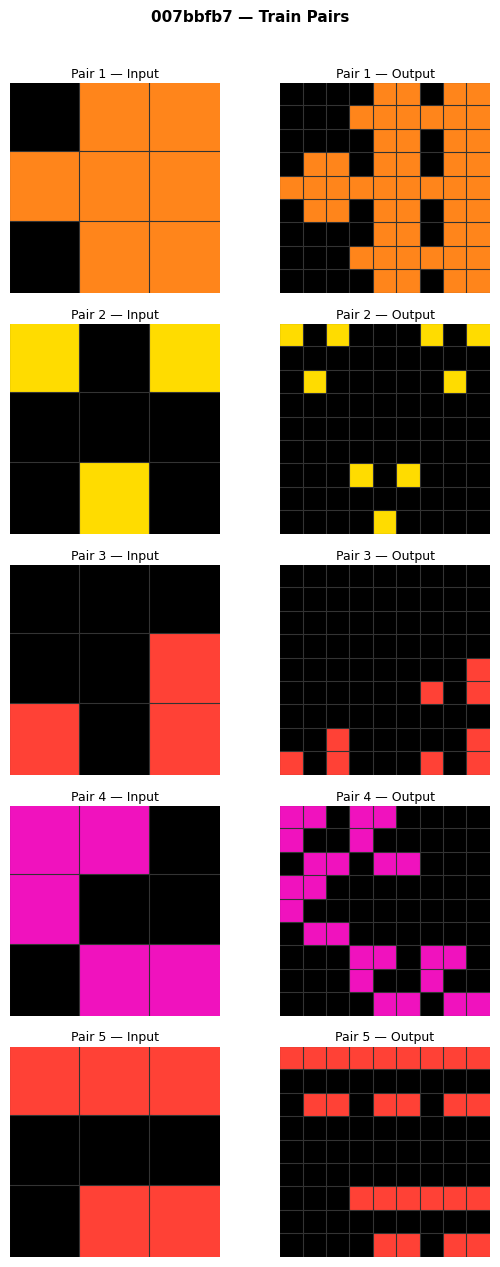

In [3]:
def draw_grid(ax, grid, title=""):
    rows = len(grid)
    cols = max(len(r) for r in grid) if grid else 1
    for r, row in enumerate(grid):
        for c, val in enumerate(row):
            color = ARC_COLORS.get(val, "#000000")
            rect = mpatches.FancyBboxPatch(
                (c, rows - r - 1), 1, 1,
                boxstyle="square,pad=0.02",
                facecolor=color, edgecolor="#333333", linewidth=0.8,
            )
            ax.add_patch(rect)
    ax.set_xlim(0, cols)
    ax.set_ylim(0, rows)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, fontsize=9, pad=4)


def visualize_pairs(pairs, title=""):
    n = len(pairs)
    fig, axes = plt.subplots(n, 2, figsize=(6, n * 2.5))
    if n == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=11, fontweight="bold", y=1.01)
    for i, (ax_row, pair) in enumerate(zip(axes, pairs)):
        draw_grid(ax_row[0], pair.input,  f"Pair {i+1} — Input")
        draw_grid(ax_row[1], pair.output, f"Pair {i+1} — Output")
    plt.tight_layout()
    plt.show()


visualize_pairs(task.train, title=f"{task.task_id} — Train Pairs")

## 3. Visualize test pair(s)

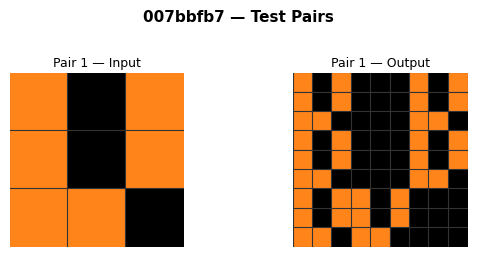

In [4]:
visualize_pairs(task.test, title=f"{task.task_id} — Test Pairs")

## 4. Inspect the LLM prompt (dry run)

In [5]:
# LOO iteration 0: hold out train[0], use train[1:] as demos
demo_pairs = task.train[1:]
test_input  = task.train[0].input

prompt = build_prompt(demo_pairs, test_input)
print(prompt)

## Demonstration pairs:
Pair 1:
Input:
4 0 4
0 0 0
0 4 0

Output:
4 0 4 0 0 0 4 0 4
0 0 0 0 0 0 0 0 0
0 4 0 0 0 0 0 4 0
0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0
0 0 0 4 0 4 0 0 0
0 0 0 0 0 0 0 0 0
0 0 0 0 4 0 0 0 0

Pair 2:
Input:
0 0 0
0 0 2
2 0 2

Output:
0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 2
0 0 0 0 0 0 2 0 2
0 0 0 0 0 0 0 0 0
0 0 2 0 0 0 0 0 2
2 0 2 0 0 0 2 0 2

Pair 3:
Input:
6 6 0
6 0 0
0 6 6

Output:
6 6 0 6 6 0 0 0 0
6 0 0 6 0 0 0 0 0
0 6 6 0 6 6 0 0 0
6 6 0 0 0 0 0 0 0
6 0 0 0 0 0 0 0 0
0 6 6 0 0 0 0 0 0
0 0 0 6 6 0 6 6 0
0 0 0 6 0 0 6 0 0
0 0 0 0 6 6 0 6 6

Pair 4:
Input:
2 2 2
0 0 0
0 2 2

Output:
2 2 2 2 2 2 2 2 2
0 0 0 0 0 0 0 0 0
0 2 2 0 2 2 0 2 2
0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0
0 0 0 2 2 2 2 2 2
0 0 0 0 0 0 0 0 0
0 0 0 0 2 2 0 2 2

## Test input:
0 7 7
7 7 7
0 7 7


## 5. Run LOO on this task  *(requires OPENAI_API_KEY)*

In [6]:
from langchain_openai import ChatOpenAI
from src.hypothesis_agent import build_chain

MODEL = "gpt-4.1-mini"   # change to gpt-4o for better results
llm = ChatOpenAI(model=MODEL, temperature=0)
chain = build_chain(llm)

# Jupyter supports top-level await
task_result = await run_task_loo(task, chain=chain, model=MODEL)

print(f"LOO accuracy:  {task_result.loo_accuracy:.2f}  ({sum(r.exact_match for r in task_result.loo_results)}/{len(task_result.loo_results)} exact)")
print(f"Test accuracy: {task_result.test_accuracy:.2f}  ({sum(r.exact_match for r in task_result.test_results)}/{len(task_result.test_results)} exact)")

LOO accuracy:  0.00  (0/5 exact)
Test accuracy: 0.00  (0/1 exact)


## 6. Visualize LOO predictions vs ground truth

=== LOO predictions ===


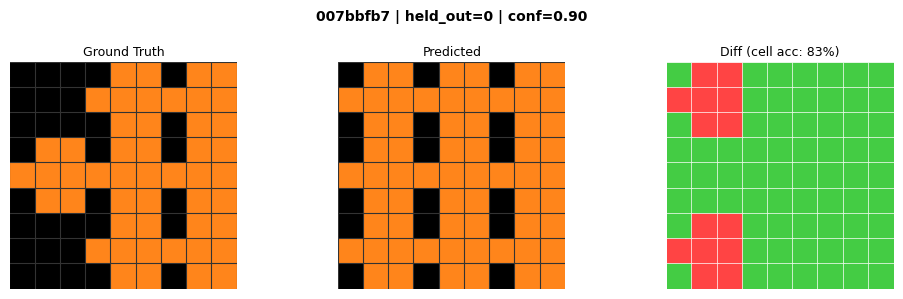

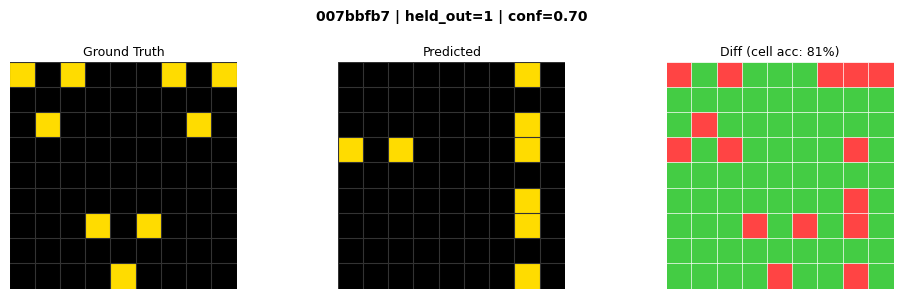

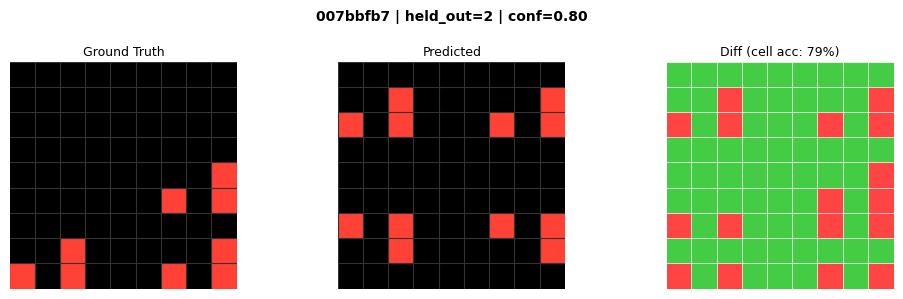

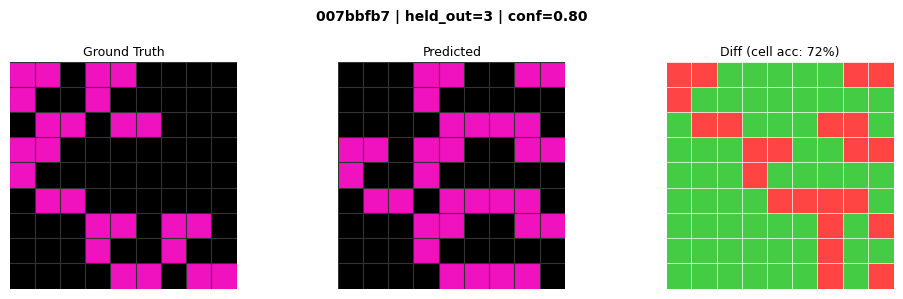

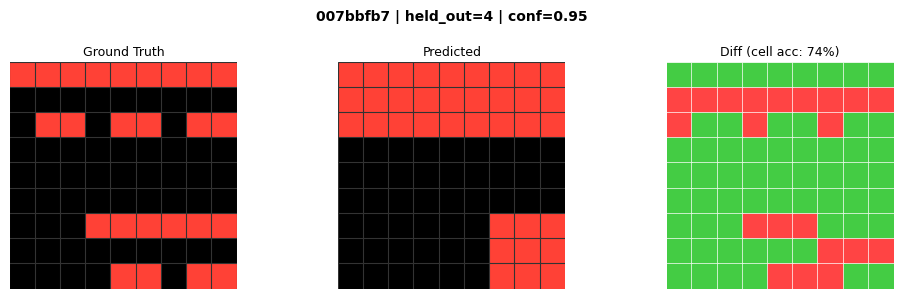

In [7]:
def visualize_prediction(result, title=""):
    """Show predicted vs actual side by side, with diff overlay."""
    predicted = result.predicted_output
    actual    = result.actual_output
    diff      = grid_diff(predicted, actual)
    mismatches = set(diff["mismatches"])

    fig, axes = plt.subplots(1, 3, figsize=(10, 3))
    draw_grid(axes[0], actual,    "Ground Truth")
    draw_grid(axes[1], predicted, "Predicted")

    # Diff panel: green = match, red = mismatch, grey = size issue
    ax = axes[2]
    if diff["size_match"] and predicted:
        rows = len(predicted)
        cols = len(predicted[0])
        for r in range(rows):
            for c in range(cols):
                color = "#ff4444" if (r, c) in mismatches else "#44cc44"
                rect = mpatches.FancyBboxPatch(
                    (c, rows - r - 1), 1, 1,
                    boxstyle="square,pad=0.02",
                    facecolor=color, edgecolor="white", linewidth=0.5,
                )
                ax.add_patch(rect)
        ax.set_xlim(0, cols)
        ax.set_ylim(0, rows)
    else:
        ax.text(0.5, 0.5, "Size\nMismatch", ha="center", va="center",
                fontsize=12, color="red", transform=ax.transAxes)

    match_str = "EXACT MATCH" if result.exact_match else f"cell acc: {diff['cell_accuracy']:.0%}"
    ax.set_title(f"Diff ({match_str})", fontsize=9, pad=4)
    ax.set_aspect("equal")
    ax.axis("off")

    label = f"held_out={result.held_out_index}" if not result.is_test else "test"
    fig.suptitle(f"{title} | {label} | conf={result.confidence:.2f}",
                 fontsize=10, fontweight="bold")
    plt.tight_layout()
    plt.show()


print("=== LOO predictions ===")
for r in task_result.loo_results:
    visualize_prediction(r, title=task.task_id)

=== Test predictions ===


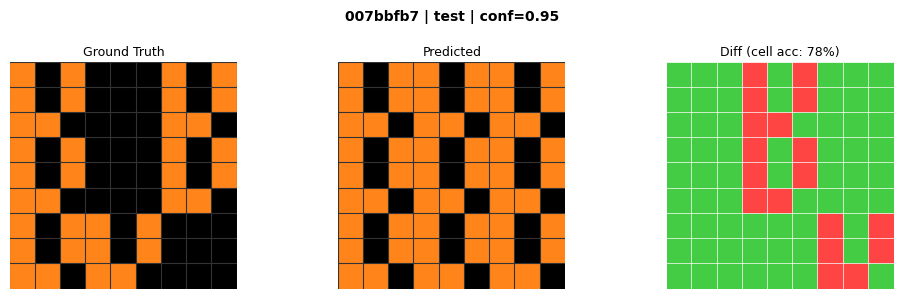

In [8]:
print("=== Test predictions ===")
for r in task_result.test_results:
    visualize_prediction(r, title=task.task_id)

## 6b. Refined predictions (self-correction pass)

Refined 5/5 LOO predictions
LOO accuracy:          0.00
Refined LOO accuracy:  0.80


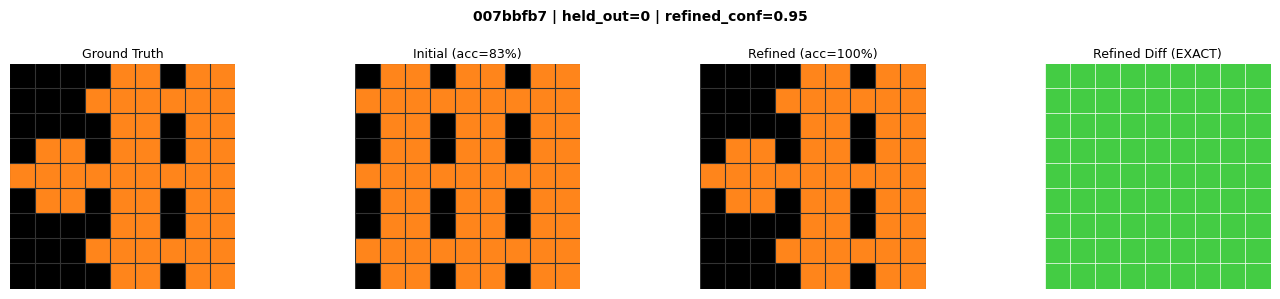

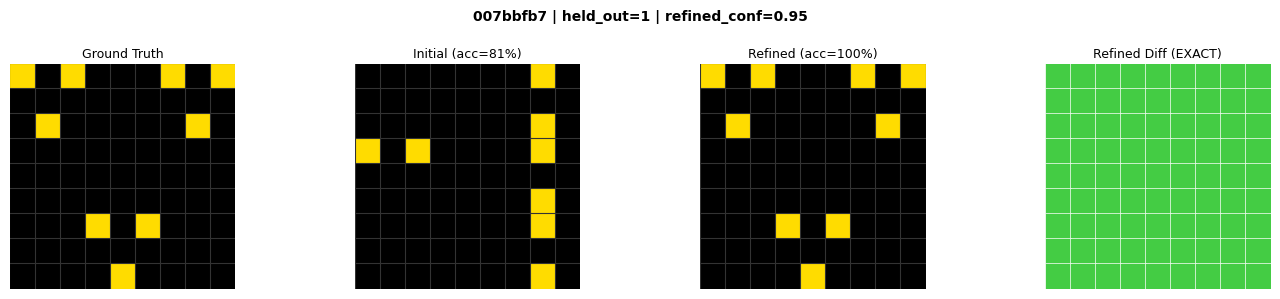

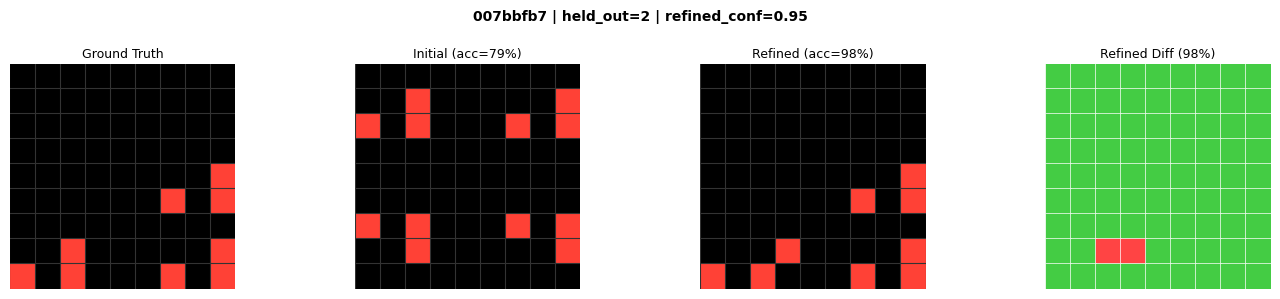

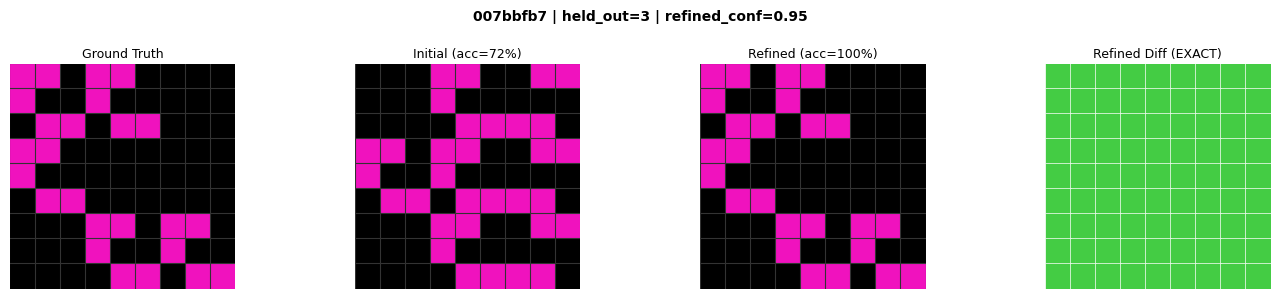

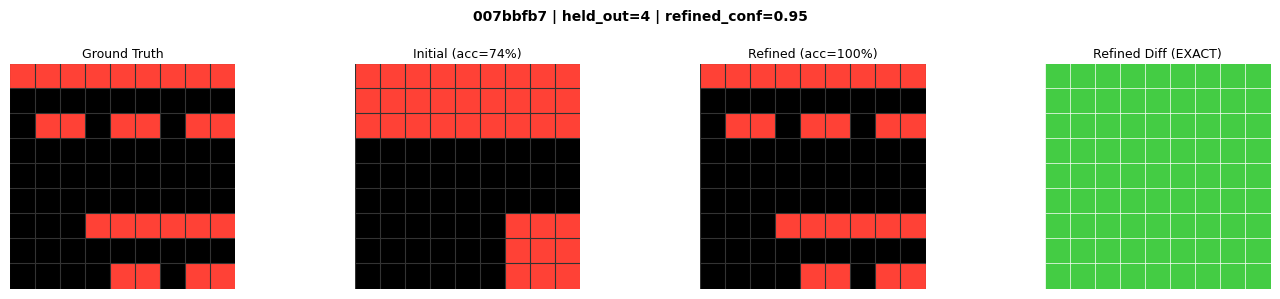

In [9]:
def visualize_refined(result, title=""):
    """4-panel: ground truth / initial predicted / refined predicted / refined diff."""
    if result.refined_predicted_output is None:
        return
    predicted  = result.predicted_output
    refined    = result.refined_predicted_output
    actual     = result.actual_output
    diff       = grid_diff(refined, actual)
    mismatches = set(diff["mismatches"])

    fig, axes = plt.subplots(1, 4, figsize=(14, 3))
    draw_grid(axes[0], actual,     "Ground Truth")
    draw_grid(axes[1], predicted,  f"Initial (acc={result.cell_accuracy:.0%})")
    draw_grid(axes[2], refined,    f"Refined (acc={result.refined_cell_accuracy:.0%})")

    ax = axes[3]
    if diff["size_match"] and refined:
        rows, cols = len(refined), len(refined[0])
        for r in range(rows):
            for c in range(cols):
                color = "#ff4444" if (r, c) in mismatches else "#44cc44"
                rect = mpatches.FancyBboxPatch(
                    (c, rows - r - 1), 1, 1,
                    boxstyle="square,pad=0.02",
                    facecolor=color, edgecolor="white", linewidth=0.5,
                )
                ax.add_patch(rect)
        ax.set_xlim(0, cols)
        ax.set_ylim(0, rows)
    else:
        ax.text(0.5, 0.5, "Size\nMismatch", ha="center", va="center",
                fontsize=12, color="red", transform=ax.transAxes)

    match_str = "EXACT" if result.refined_exact_match else f"{diff['cell_accuracy']:.0%}"
    ax.set_title(f"Refined Diff ({match_str})", fontsize=9, pad=4)
    ax.set_aspect("equal")
    ax.axis("off")

    label = f"held_out={result.held_out_index}"
    fig.suptitle(f"{title} | {label} | refined_conf={result.refined_confidence:.2f}",
                 fontsize=10, fontweight="bold")
    plt.tight_layout()
    plt.show()


refined_count = sum(1 for r in task_result.loo_results if r.refined_predicted_output is not None)
print(f"Refined {refined_count}/{len(task_result.loo_results)} LOO predictions")
print(f"LOO accuracy:          {task_result.loo_accuracy:.2f}")
print(f"Refined LOO accuracy:  {task_result.refined_loo_accuracy:.2f}")

for r in task_result.loo_results:
    visualize_refined(r, title=task.task_id)

## 6c. Master synthesis (unified hypothesis)

Unified hypothesis:
  The output is a 9x9 grid composed of nine 3x3 blocks arranged in a 3x3 pattern. Each 3x3 block corresponds to a cell in the input 3x3 grid. For each cell in the input grid, if the cell's value is nonzero, the corresponding 3x3 block in the output is filled with the entire input 3x3 grid; if the cell's value is zero, the corresponding 3x3 block is filled with zeros. This creates a tiled pattern where the input grid is repeated in blocks corresponding to nonzero input cells, and zero blocks correspond to zero input cells.

Key insight:
  The key insight is that the output is a 9x9 grid formed by tiling the input 3x3 grid in a 3x3 pattern, but the presence or absence of each 3x3 tile in the output depends on the corresponding cell in the input grid. Specifically, each 3x3 block in the output corresponds to a cell in the input grid, and that block is filled with the input grid if the corresponding input cell is nonzero; otherwise, that block is filled with zeros. Thus

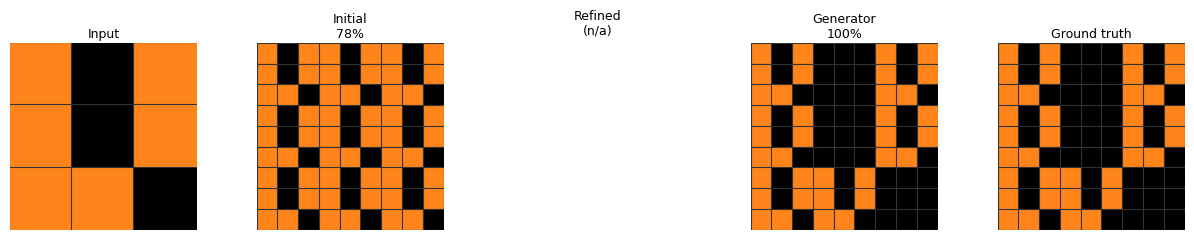

In [10]:
from src.grid_utils import grids_match, grid_diff

mr = task_result.master_result
gen_results = task_result.generator_results

if mr and mr.unified_hypothesis:
    print(f"Unified hypothesis:\n  {mr.unified_hypothesis}\n")
    print(f"Key insight:\n  {mr.key_insight}\n")
    print(f"Agreements:    {mr.agreements}")
    print(f"Disagreements: {mr.disagreements}\n")
    print(f"Master train accuracy: {mr.master_train_accuracy:.1%}")
    print("Per-pair verification (train pairs):")
    for i, ok in enumerate(mr.train_exact_matches):
        print(f"  train[{i}]: {'✓' if ok else '✗'}")

if gen_results:
    print(f"\nGenerator predicted {len(gen_results)} test output(s):")
    for j, gen_r in enumerate(gen_results):
        actual = task.test[j].output
        test_r = task_result.test_results[j]
        gen_grid = gen_r.predicted_output
        initial_grid = test_r.predicted_output
        refined_grid = test_r.refined_predicted_output

        initial_acc = test_r.cell_accuracy
        gen_acc = grid_diff(gen_grid, actual)["cell_accuracy"] if gen_grid else 0.0
        gen_match = grids_match(gen_grid, actual) if gen_grid else False

        print(f"\nTest {j}:")
        print(f"  Initial:   exact_match={test_r.exact_match}, cell_accuracy={initial_acc:.1%}")
        if refined_grid is not None:
            refined_acc = test_r.refined_cell_accuracy or 0.0
            print(f"  Refined:   exact_match={test_r.refined_exact_match}, cell_accuracy={refined_acc:.1%}")
        print(f"  Generator: exact_match={gen_match}, cell_accuracy={gen_acc:.1%}")
        if gen_r.step_by_step_trace:
            print(f"  Trace: {gen_r.step_by_step_trace[:200]}")

        fig, axes = plt.subplots(1, 5, figsize=(12.5, 2.5))
        draw_grid(axes[0], task.test[j].input, title="Input")
        draw_grid(axes[1], initial_grid, title=f"Initial\n{initial_acc:.0%}")
        if refined_grid is not None:
            draw_grid(axes[2], refined_grid, title=f"Refined\n{test_r.refined_cell_accuracy:.0%}")
        else:
            axes[2].set_title("Refined\n(n/a)", fontsize=9)
            axes[2].axis("off")
        if gen_grid:
            draw_grid(axes[3], gen_grid, title=f"Generator\n{gen_acc:.0%}")
        else:
            axes[3].set_title("Generator\n(failed)", fontsize=9)
            axes[3].axis("off")
        draw_grid(axes[4], actual, title="Ground truth")
        plt.tight_layout()
        plt.show()
else:
    print("No generator results available.")

## 7. Per-task metrics

In [11]:
from src.evaluate import evaluate_task
metrics = evaluate_task(task_result)

for k, v in metrics.items():
    print(f"  {k}: {v:.3f}" if isinstance(v, float) else f"  {k}: {v}")

  task_id: 007bbfb7
  loo_exact_match_rate: 0.000
  test_exact_match_rate: 0.000
  mean_cell_accuracy: 0.778
  num_loo_pairs: 5
  num_test_pairs: 1


## 8. Inspect a specific LOO hypothesis

In [11]:
# Change index to inspect different LOO results
for i in range(4):
    
    r = task_result.loo_results[i]

    print(f"Held out: train[{r.held_out_index}]")
    print(f"Exact match: {r.exact_match}  |  Cell accuracy: {r.cell_accuracy:.2%}  |  Confidence: {r.confidence:.2f}")
    print(f"\nHypothesis:\n  {r.hypothesis}")
    print(f"\nReasoning:\n  {r.reasoning}")
    print(f"\nRefined Hypothesis:\n  {r.refined_hypothesis}")
    print(f"\nRefined Reasoning:\n  {r.refined_reasoning}")

Held out: train[0]
Exact match: False  |  Cell accuracy: 82.72%  |  Confidence: 0.95

Hypothesis:
  The output is a 9x9 grid formed by tiling the 3x3 input grid in a 3x3 pattern, where each tile is the original input grid. The output grid is constructed by placing the input grid repeatedly in a 3x3 arrangement, resulting in a 9x9 grid where each 3x3 block corresponds to the input grid.

Reasoning:
  In all demonstration pairs, the output grid is 9x9, which is exactly 3 times the size of the 3x3 input grid in both dimensions. The output appears to be composed of 9 tiles of the input grid arranged in a 3x3 pattern. Each tile is identical to the input grid, placed without overlap or modification. This tiling pattern explains the output grids in all examples.

Refined Hypothesis:
  The output is a 9x9 grid formed by tiling the input 3x3 grid in a 3x3 pattern, but with a masking rule applied: in the leftmost 3 columns of the output grid, any cell that corresponds to a zero in the first colu

In [12]:
refined    = r.refined_predicted_output
actual     = r.actual_output
diff       = grid_diff(refined, actual)
print(diff)

def _describe_errors(mismatches: list[tuple[int, int]], rows: int, cols: int) -> str:
    """Summarise mismatch positions as a human-readable spatial description."""
    if not mismatches:
        return "no errors"

    def _range_str(indices: list[int]) -> str:
        return str(indices[0]) if len(indices) == 1 else f"{indices[0]}-{indices[-1]}"

    error_rows = sorted({r for r, _ in mismatches})
    error_cols = sorted({c for _, c in mismatches})
    return (
        f"{len(mismatches)} cell(s) incorrect; "
        f"errors in rows {_range_str(error_rows)}, "
        f"cols {_range_str(error_cols)} "
        f"(grid is {rows}\u00d7{cols})"
    )

rows = len(refined)
cols = len(refined[0]) if refined else 0
cell_acc_pct = round(diff["cell_accuracy"] * 100, 1)
error_desc = _describe_errors(diff["mismatches"], rows, cols)
print(error_desc)

{'size_match': True, 'cell_accuracy': 0.7654320987654321, 'mismatches': [(0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 1), (2, 2), (3, 1), (3, 2), (4, 0), (4, 1), (4, 2), (4, 3), (5, 1), (5, 2), (6, 6), (7, 3), (7, 4), (7, 5)]}
19 cell(s) incorrect; errors in rows 0-7, cols 0-6 (grid is 9×9)
